# Geographic price overview

Where are the expensive listings in Almaty, and how price decays with distance from the city centre.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path('..') / 'datasets' / 'processed' / 'ads_model_v1.csv'
df = pd.read_csv(DATA_PATH)
df['price_per_m2'] = df['target_price_kzt'] / df['area_m2']
df.shape

(38762, 128)

## 1. Listings on the map, colored by price per m²

Color is clamped to the 5th-95th percentile of price/m² so a few luxury outliers don't wash out the gradient.

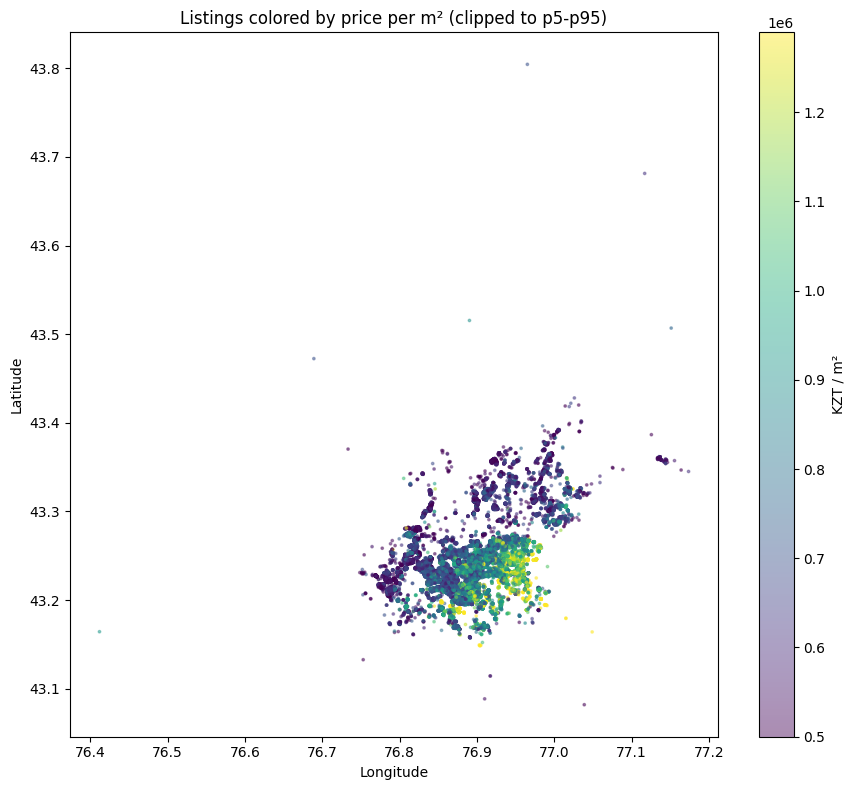

In [2]:
low, high = df['price_per_m2'].quantile([0.05, 0.95])

fig, ax = plt.subplots(figsize=(9, 8))
scatter = ax.scatter(
    df['lon'], df['lat'],
    c=df['price_per_m2'].clip(low, high),
    cmap='viridis', s=3, alpha=0.45,
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Listings colored by price per m² (clipped to p5-p95)')
fig.colorbar(scatter, ax=ax, label='KZT / m²')
plt.tight_layout()
plt.show()

What this shows: the south-east cluster (Medeu / Bostandyk, ~43.20-43.25 lat) is the most expensive zone. The north-west periphery (Alatau / Turksib) drops to roughly half the price per m². There is a clear concentric pattern centred on the historic centre.

## 2. Price per m² vs distance to city centre

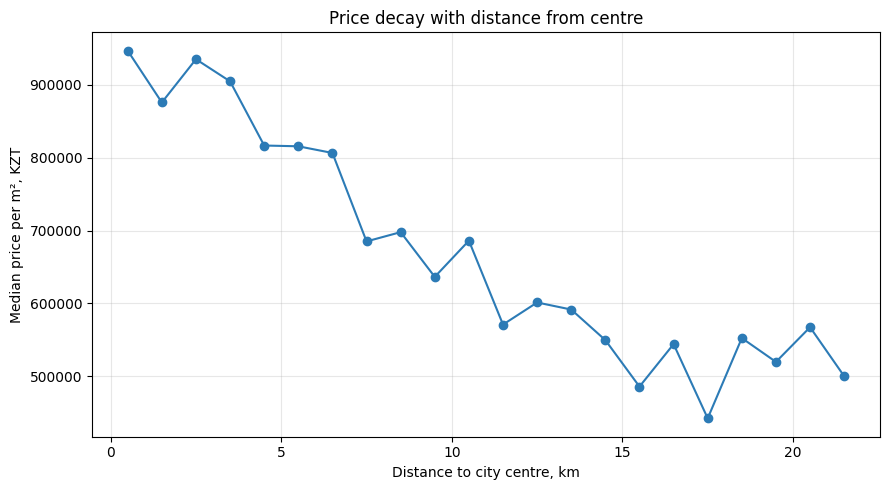

In [3]:
bins = pd.cut(df['dist_to_center_km'], bins=np.arange(0, 25, 1))
binned = df.groupby(bins, observed=True)['price_per_m2'].agg(['median', 'count']).reset_index()
binned['mid_km'] = binned['dist_to_center_km'].apply(lambda i: i.mid)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(binned['mid_km'], binned['median'], marker='o', color='#2c7bb6')
ax.set_xlabel('Distance to city centre, km')
ax.set_ylabel('Median price per m², KZT')
ax.set_title('Price decay with distance from centre')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

What this shows: median price/m² drops monotonically with distance to centre for the first ~12 km, then plateaus. The first 3 km premium is roughly 1.5-2× the outer-ring price, which explains why `dist_to_center_km` is a strong feature in tree splits.

## 3. Median price per m² by district

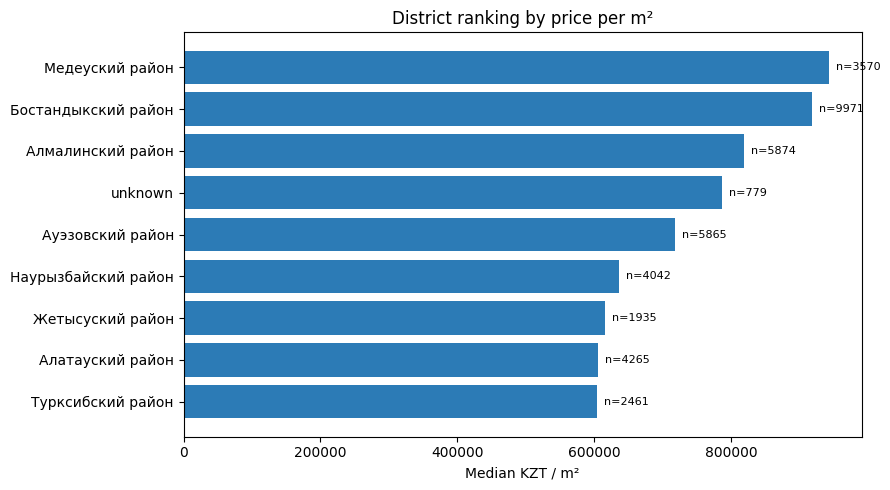

In [4]:
district_stats = (
    df.groupby('district')
    .agg(listings=('price_per_m2', 'size'), median_ppm2=('price_per_m2', 'median'))
    .sort_values('median_ppm2')
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(district_stats.index, district_stats['median_ppm2'], color='#2c7bb6')
for i, (count, val) in enumerate(zip(district_stats['listings'], district_stats['median_ppm2'])):
    ax.text(val, i, f'  n={count}', va='center', fontsize=8)
ax.set_xlabel('Median KZT / m²')
ax.set_title('District ranking by price per m²')
plt.tight_layout()
plt.show()

What this shows: Medeu and Bostandyk are at the top with roughly ~1M KZT/m². Alatau, Turksib and Zhetysu sit at the bottom, around half that. The price gap between best and worst district is roughly 2×, with Bostandyk also being the densest market (most listings).